**LangGraph**

In [1]:
import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root) 
from agents.car.agent import build_car_graph 

# Khởi tạo graph (cần dùng await vì hàm này là async)
graph = await build_car_graph()

c:\Program Files\Python312\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


**Test**

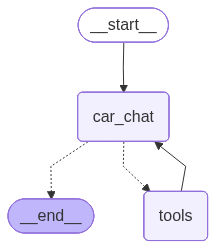

In [3]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [2]:
from langchain_core.messages import AIMessage

async def stream_graph_updates(inputs: dict):
    async for event in graph.astream(inputs):
        if "car_chat" in event:
            for msg in event["car_chat"].get("messages", []):
                # In tham số tool — đây là chỗ cần check
                if isinstance(msg, AIMessage) and msg.tool_calls:
                    for tc in msg.tool_calls:
                        print("🔧 Tool:", tc["name"])
                        print("📥 Args:", tc["args"])

                if hasattr(msg, "content") and msg.content:
                    print("Assistant:", msg.content)

        if "tools" in event:
            for msg in event["tools"].get("messages", []):
                if hasattr(msg, "content") and msg.content:
                    print("Tool Output:", msg.content)

In [3]:
test_cases = [

    "Tìm kiếm chỗ cho thuê xe ở Hà Nội từ 10/7 đến 12/7."
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs) 


🧑‍💻 User: Tìm kiếm chỗ cho thuê xe ở Hà Nội từ 10/7 đến 12/7.
{'messages': [{'role': 'user', 'content': 'Tìm kiếm chỗ cho thuê xe ở Hà Nội từ 10/7 đến 12/7.'}]}
🔧 Tool: search_cars_tool
📥 Args: {'end_ms': '2026-07-12 23:59', 'address': 'Hà Nội', 'start_ms': '2026-07-10 00:00'}
Tool Output: [{'type': 'text', 'text': '{\n  "count": 10,\n  "cars": [\n    {\n      "car_id": "KKVPUG",\n      "Tên xe": "MAZDA 3 Deluxe 2017",\n      "Giá gốc": "899K",\n      "Hộp số": "Số tự động",\n      "Số chỗ": "4 chỗ",\n      "Nhiên liệu": "Xăng",\n      "Địa chỉ": "Phường Kim Liên, Quận Đống Đa",\n      "Rating": "5.0",\n      "Số chuyến": "100+ chuyến",\n      "Tags": "Giao xe tận nơi",\n      "Ảnh": "https://n1-pstg.mioto.vn/cho_thue_xe_o_to_tu_lai_thue_xe_du_lich_hanoi/mazda_3_deluxe_2017/p/g/2023/08/21/15/vmLYtrtrUlir3TpF9IwzBQ.jpg",\n      "Link": "https://www.mioto.vn/car/mazda-3-deluxe-2017/KKVPUG"\n    },\n    {\n      "car_id": "KIDFDR",\n      "Tên xe": "MG5 STANDARD 2024",\n      "Giá gốc": 

In [3]:
test_cases = [

    "Tìm kiếm chỗ cho thuê xe điện ở Hà Nội từ 10/7 đến 12/7."
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs) 


🧑‍💻 User: Tìm kiếm chỗ cho thuê xe điện ở Hà Nội từ 10/7 đến 12/7.
{'messages': [{'role': 'user', 'content': 'Tìm kiếm chỗ cho thuê xe điện ở Hà Nội từ 10/7 đến 12/7.'}]}
🔧 Tool: search_cars_tool
📥 Args: {'user_needs': 'xe điện', 'end_ms': '2026-07-12 23:59', 'address': 'Hà Nội', 'start_ms': '2026-07-10 00:00'}
Tool Output: [{'type': 'text', 'text': '{\n  "count": 10,\n  "cars": [\n    {\n      "car_id": "KL3XHY",\n      "Tên xe": "VINFAST LIMO GREEN 2026",\n      "Giá gốc": "1.359K",\n      "Hộp số": "Số tự động",\n      "Số chỗ": "7 chỗ",\n      "Nhiên liệu": "Điện",\n      "Địa chỉ": "Phường Hàng Bột, Quận Đống Đa",\n      "Rating": "5.0",\n      "Số chuyến": "2 chuyến",\n      "Tags": "Giao xe tận nơi",\n      "Ảnh": "https://n1-pstg.mioto.vn/cho_thue_xe_o_to_tu_lai_thue_xe_du_lich_hanoi/vinfast_limo_green_2026/p/g/2026/05/01/11/V7wPRgm01PkAoh6Aisu-Dw.jpg",\n      "Link": "https://www.mioto.vn/car/vinfast-limo-green-2026/KL3XHY"\n    },\n    {\n      "car_id": "KHXXK7",\n      "Tê

In [3]:
test_cases = [

    "Tìm kiếm chỗ cho thuê xe để đi với gia đình ở Đà Nẵng từ 10/7 đến 12/7."
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs) 


🧑‍💻 User: Tìm kiếm chỗ cho thuê xe để đi với gia đình ở Đà Nẵng từ 10/7 đến 12/7.
{'messages': [{'role': 'user', 'content': 'Tìm kiếm chỗ cho thuê xe để đi với gia đình ở Đà Nẵng từ 10/7 đến 12/7.'}]}
🔧 Tool: search_cars_tool
📥 Args: {'start_ms': '2026-07-10 00:00', 'end_ms': '2026-07-12 23:59', 'address': 'Đà Nẵng', 'user_needs': 'đi với gia đình'}
Tool Output: [{'type': 'text', 'text': '{\n  "count": 10,\n  "cars": [\n    {\n      "car_id": "KGASGK",\n      "Tên xe": "MITSUBISHI XPANDER 2023",\n      "Giá gốc": "1.101K",\n      "Hộp số": "Số tự động",\n      "Số chỗ": "7 chỗ",\n      "Nhiên liệu": "Xăng",\n      "Địa chỉ": "Phường Thạch Thang, Quận Hải Châu",\n      "Rating": "5.0",\n      "Số chuyến": "36 chuyến",\n      "Tags": "Miễn thế chấp, Giao xe tận nơi",\n      "Ảnh": "https://n1-pstg.mioto.vn/cho_thue_xe_o_to_tu_lai_thue_xe_du_lich_danang/mitsubishi_xpander_2023/p/g/2023/10/19/09/H_T4uEjzI0lyglsa0x-N9Q.jpg",\n      "Link": "https://www.mioto.vn/car/mitsubishi-xpander-2023/

In [5]:
test_cases = [

    "Tìm kiếm chỗ cho thuê xe để đi với gia đình ở Đà Nẵng, giá nhiều nhất là 900000 từ 19/7 đến 21/7."
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs) 


🧑‍💻 User: Tìm kiếm chỗ cho thuê xe để đi với gia đình ở Đà Nẵng, giá nhiều nhất là 900000 từ 19/7 đến 21/7.
{'messages': [{'role': 'user', 'content': 'Tìm kiếm chỗ cho thuê xe để đi với gia đình ở Đà Nẵng, giá nhiều nhất là 900000 từ 19/7 đến 21/7.'}]}
🔧 Tool: search_cars_tool
📥 Args: {'user_needs': 'đi với gia đình', 'end_ms': '2026-07-21 23:59', 'address': 'Đà Nẵng', 'max_price': 900000.0, 'start_ms': '2026-07-19 00:00'}
Tool Output: [{'type': 'text', 'text': '{\n  "count": 8,\n  "cars": [\n    {\n      "car_id": "KFAF6T",\n      "Tên xe": "PEUGEOT 3008 2018",\n      "Giá sau giảm": "Không có",\n      "Giá gốc": "899K",\n      "Hộp số": "Số tự động",\n      "Số chỗ": "5 chỗ",\n      "Nhiên liệu": "Xăng",\n      "Địa chỉ": "Phường Thạc Gián, Quận Thanh Khê",\n      "Rating": "5.0",\n      "Số chuyến": "17 chuyến",\n      "Tags": "Miễn thế chấp, Giao xe tận nơi",\n      "Ảnh": "https://n1-pstg.mioto.vn/cho_thue_xe_o_to_tu_lai_thue_xe_du_lich_danang/peugeot_3008_2018/p/g/2026/03/19/12/

In [3]:
test_cases = [

    "Tìm kiếm biết thông tin chi tiết ve xe VINFAST VF6 PLUS 2026 co ma KKG4MH."
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs) 


🧑‍💻 User: Tìm kiếm biết thông tin chi tiết ve xe VINFAST VF6 PLUS 2026 co ma KKG4MH.
{'messages': [{'role': 'user', 'content': 'Tìm kiếm biết thông tin chi tiết ve xe VINFAST VF6 PLUS 2026 co ma KKG4MH.'}]}
🔧 Tool: get_car_details_tool
📥 Args: {'car_name': 'VINFAST VF6 PLUS 2026', 'car_id': 'KKG4MH'}
Tool Output: [{'type': 'text', 'text': '{\n  "Tên xe": "VINFAST VF6 PLUS 2026",\n  "Số chuyến": "4.0",\n  "Địa chỉ": "1 chuyến",\n  "Tags": [\n    "Miễn thế chấp",\n    "Giao xe tận nơi"\n  ],\n  "Ảnh": [\n    "https://www.facebook.com/tr?id=467366885531539&ev=PageView&noscript=1",\n    "https://www.facebook.com/tr?id=2228490294012835&ev=PageView&noscript=1",\n    "https://www.mioto.vn/static/media/logo-full.ea382559.png",\n    "https://n1-pstg.mioto.vn/cho_thue_xe_o_to_tu_lai_thue_xe_du_lich_danang/vinfast_vf6_plus_2026/p/g/2026/03/13/11/74AUj9rQFLzEykMLmVlg6g.jpg",\n    "https://n1-pstg.mioto.vn/cho_thue_xe_o_to_tu_lai_thue_xe_du_lich_danang/vinfast_vf6_plus_2026/p/g/2026/03/13/11/DNpYM